# Continual leg-damage adaptation — analysis

Figures for the paper from `results/continual_events.csv` (written by `run_experiment.py`). The event PERSISTS until the robot falls; each fall heals+resets it and the event re-engages after a gap. Headline metric = **falls per bout**. Reusable logic lives in `methods/continual_analysis.py`.

Regenerate results first if needed:
```bash
python experiment-damage-adapt/run_experiment.py --seeds 10 --duration 120
```

In [1]:
import os, sys
%matplotlib inline

root = os.path.abspath('')
while root != os.path.dirname(root) and not os.path.isdir(os.path.join(root, 'methods')):
    root = os.path.dirname(root)
if root not in sys.path:
    sys.path.insert(0, root)

from methods import continual_analysis as ca

EXP         = 'experiment-damage-adapt'
TITLE       = 'Continual leg-damage adaptation'
EVENT_WORD  = 'leg-damage'
EXT         = 'png'          # 'pdf' for the camera-ready
RESULTS_DIR = os.path.join(root, EXP, 'results')
FIG_DIR     = os.path.join(RESULTS_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

rows = ca.load_events(RESULTS_DIR)
print(f'loaded {len(rows)} events across arms:', ca.methods_present(rows))

loaded 141 events across arms: ['noadapt', 'grid', 'bo', 'safegp', 'oracle']


## Per-method summary
Falls per bout, stability (surviving RMS body tilt), and distance travelled — mean ± SEM across seeds.

In [2]:
ca.summary_dataframe(rows)

,seeds,falls_per_bout,falls_sem,tilt_deg,tilt_sem,dist_m,dist_sem
method,,,,,,,
No adaptation,4,11.50,0.65,7.28,0.80,14.04,0.62
Grid search,4,6.75,2.02,4.67,1.77,14.79,7.99
Bayesian opt.,4,6.75,2.29,3.29,0.36,16.55,9.83
Safe GP (ours),4,6.50,3.23,8.84,4.99,31.22,7.76
Oracle,4,0.25,0.25,3.44,0.55,47.14,1.13


## Headline: falls per bout / stability / distance
`noadapt` is the lower anchor (hatched gray), `oracle` the upper anchor; `safegp` is the proposed method. NB: under persist-until-fall a safe method stays in the slower recovery gait longer, so it can travel *less* — read distance alongside falls, not alone.

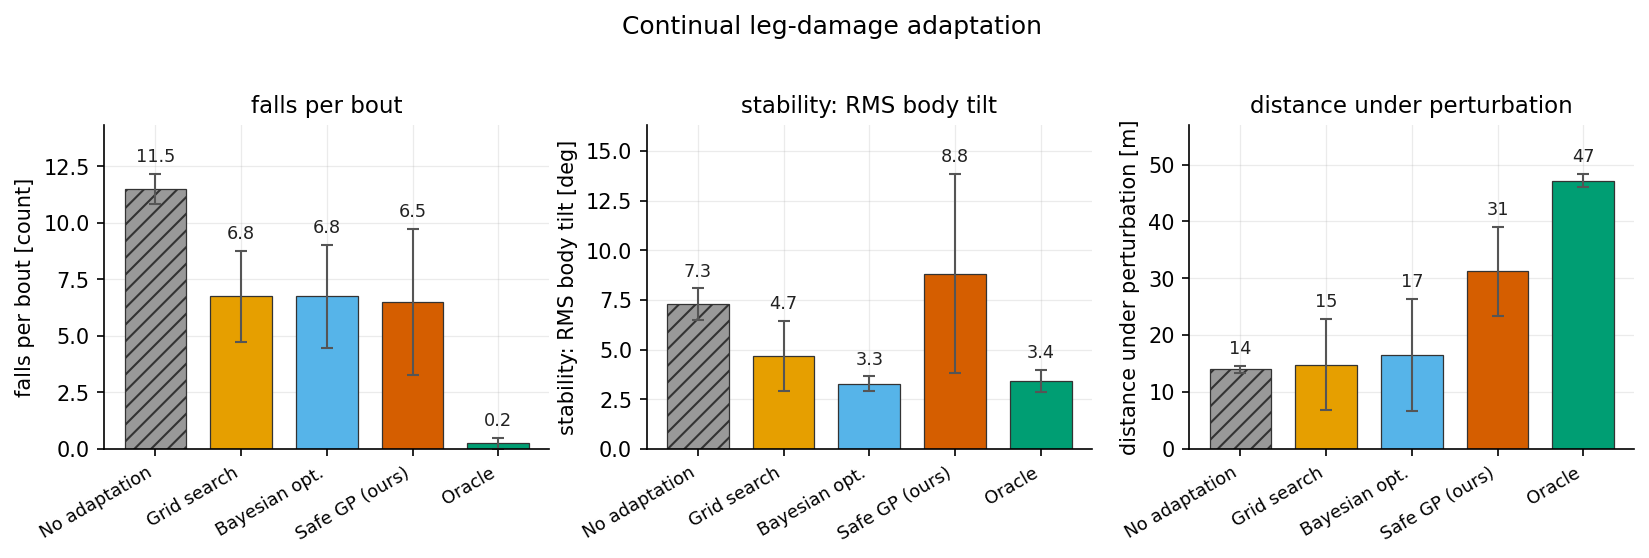

In [3]:
fig = ca.fig_comparison(rows, TITLE, EVENT_WORD,
                        out_path=os.path.join(FIG_DIR, f'method_comparison.{EXT}'))

## Cumulative falls over the bout
Mean cumulative falls vs time per method. `noadapt` climbs steadily; a method that learns a recovery gait plateaus; the `oracle` stays flat.

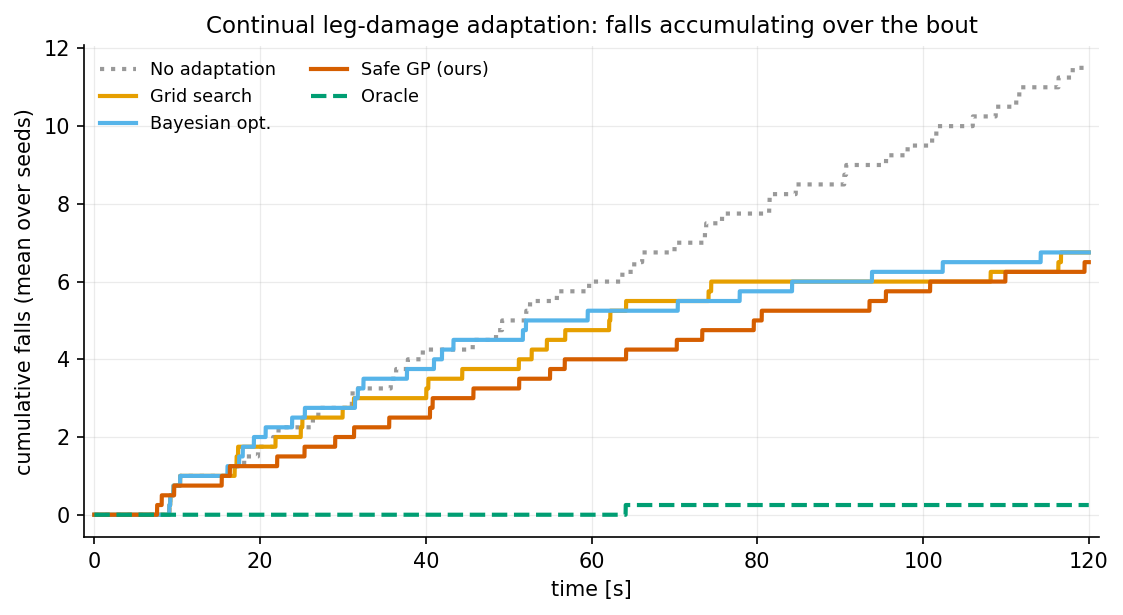

In [4]:
fig = ca.fig_falls_over_time(RESULTS_DIR, TITLE, EVENT_WORD,
                            out_path=os.path.join(FIG_DIR, f'falls_over_time.{EXT}'))

## Example time series (seed 0)
Forward-speed trace per method; orange = event engaged, green = the method's proposed gait active. Needs `results/logs/*.npz`.

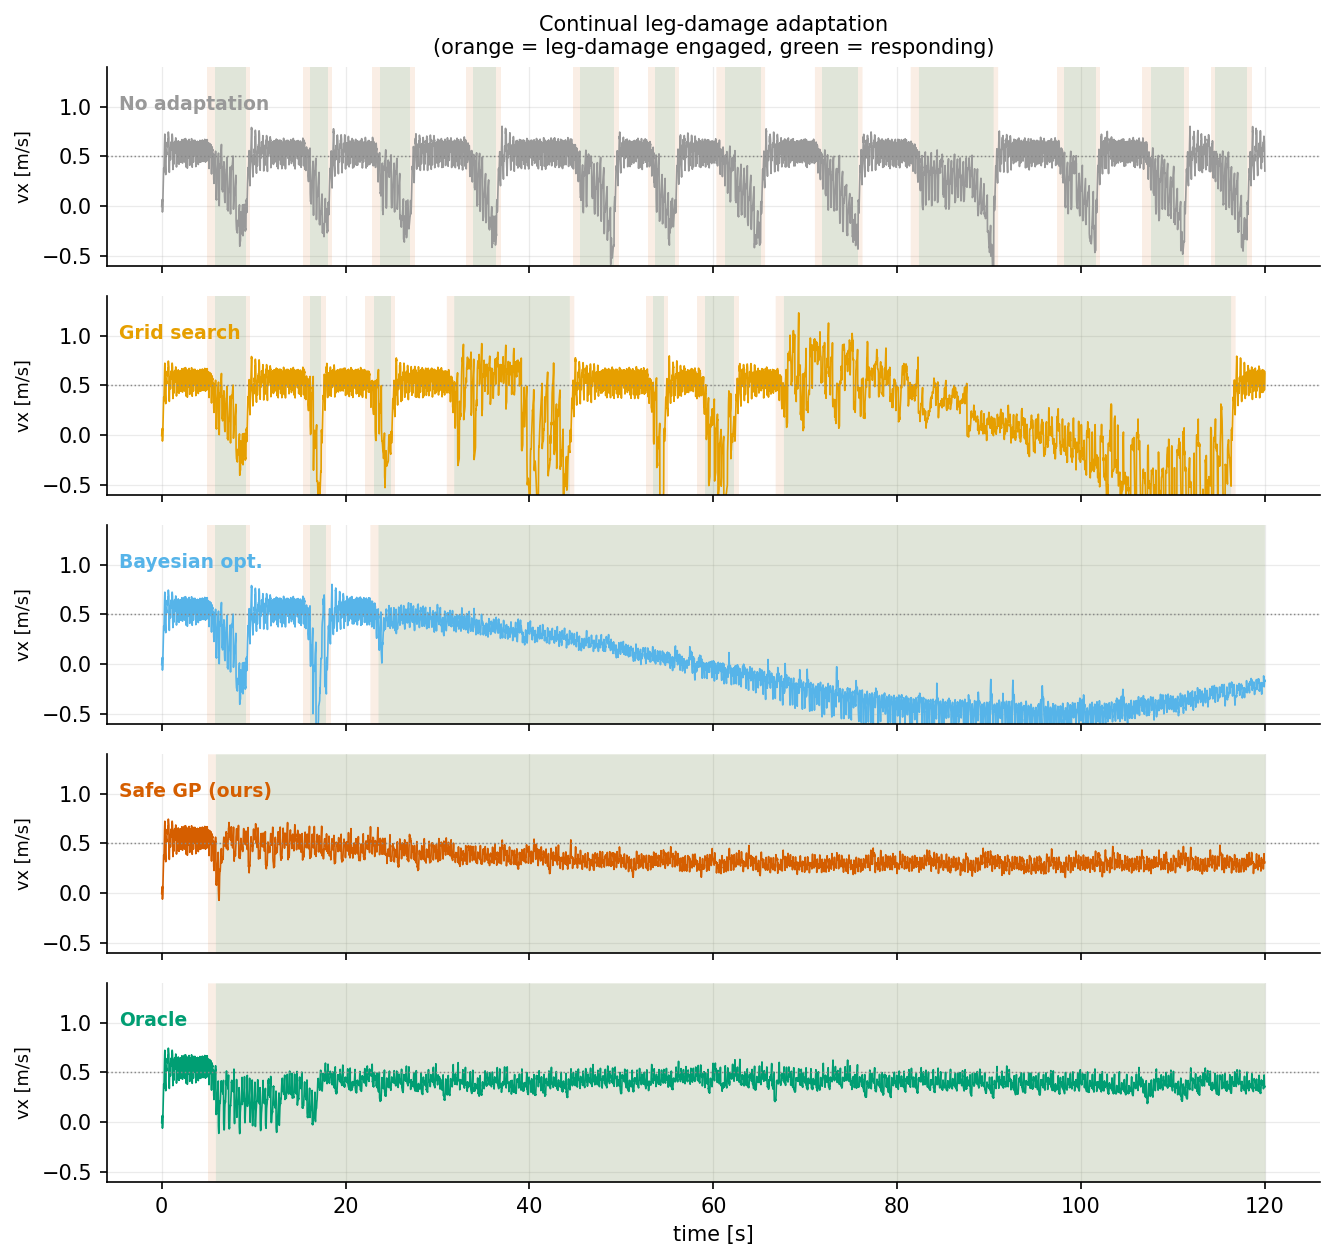

In [5]:
fig = ca.fig_timeseries(RESULTS_DIR, TITLE, EVENT_WORD, seed=0,
                        out_path=os.path.join(FIG_DIR, f'timeseries_seed0.{EXT}'))